# Pipeline 1: Donor Churn Classifier

## 1. Problem Framing

**Business question:** Which active donors are at risk of lapsing before their next expected donation?

**Who cares:** The Executive Director and fundraising staff. Donor retention is explicitly called out as a top organizational concern. The organization loses donors and doesn't know why. This model gives them an early warning system so they can do personalized outreach before a donor goes silent.

**Approach: Predictive**
This is a predictive classification problem. Our goal is to generate reliable predictions about which donors will churn — not to explain causation. We want a model that performs well on unseen donors, even if the individual coefficients are less interpretable. We chose prediction over explanation here because the actionable output is a risk score ("reach out to this donor now"), not a policy recommendation about what causes churn.

**Success metric:** We will optimize for Recall on the churned class. In this context, a false negative (predicting a donor will stay when they are actually about to leave) is more costly than a false positive (flagging a loyal donor for outreach). Missing a churning donor means losing their future contributions entirely. Unnecessary outreach to a loyal donor has low cost.

**Target variable:** Binary churn label — 1 if supporter status is Inactive, 0 if Active.


## 2. Data Acquisition, Preparation & Exploration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../lighthouse_csv_v7/lighthouse_csv_v7/'

supporters = pd.read_csv(CSV_DIR + 'supporters.csv')
donations = pd.read_csv(CSV_DIR + 'donations.csv')

print("Supporters shape:", supporters.shape)
print("Donations shape:", donations.shape)
print("\nSupporter status distribution:")
print(supporters['status'].value_counts())
print("\nSupporter types:")
print(supporters['supporter_type'].value_counts())

Supporters shape: (60, 15)
Donations shape: (420, 13)

Supporter status distribution:
status
Active      45
Inactive    15
Name: count, dtype: int64

Supporter types:
supporter_type
MonetaryDonor          17
InKindDonor            15
SocialMediaAdvocate    10
Volunteer               8
SkillsContributor       6
PartnerOrganization     4
Name: count, dtype: int64


=== Missing Values — Supporters ===
organization_name      56
first_name              4
last_name               4
first_donation_date     1
dtype: int64

=== Missing Values — Donations ===
campaign_name       275
currency_code       186
amount              186
referral_post_id    343
dtype: int64

=== Donations by type ===
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

=== Acquisition channels ===
acquisition_channel
WordOfMouth        14
SocialMedia        13
Website            13
Event               8
Church              6
PartnerReferral     6
Name: count, dtype: int64


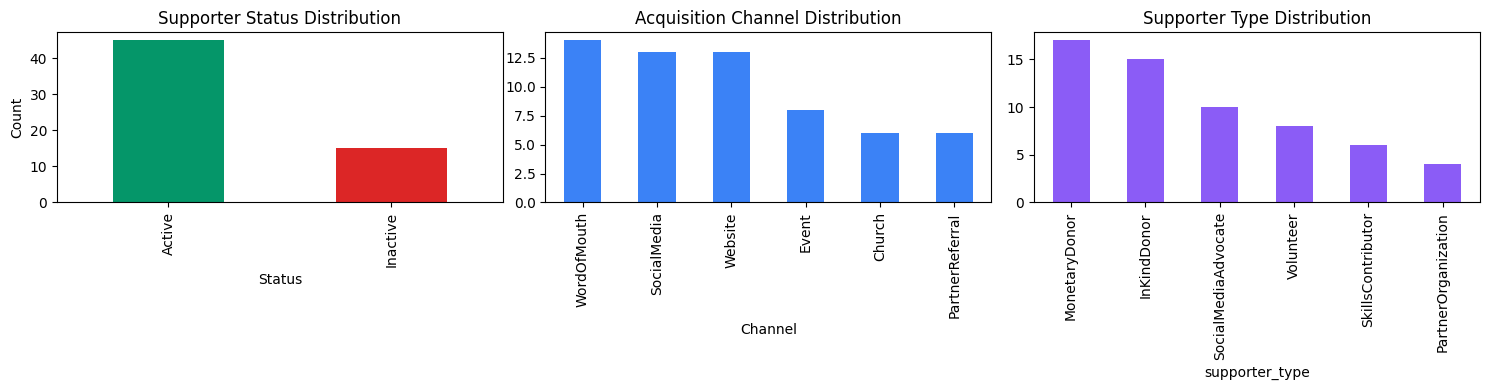

EDA charts saved.


In [2]:
# Check missing values
print("=== Missing Values — Supporters ===")
print(supporters.isnull().sum()[supporters.isnull().sum() > 0])

print("\n=== Missing Values — Donations ===")
print(donations.isnull().sum()[donations.isnull().sum() > 0])

print("\n=== Donations by type ===")
print(donations['donation_type'].value_counts())

print("\n=== Acquisition channels ===")
print(supporters['acquisition_channel'].value_counts())

# Visualize churn distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

supporters['status'].value_counts().plot(kind='bar', ax=axes[0], color=['#059669','#dc2626'])
axes[0].set_title('Supporter Status Distribution')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')

supporters['acquisition_channel'].value_counts().plot(kind='bar', ax=axes[1], color='#3b82f6')
axes[1].set_title('Acquisition Channel Distribution')
axes[1].set_xlabel('Channel')

supporters['supporter_type'].value_counts().plot(kind='bar', ax=axes[2], color='#8b5cf6')
axes[2].set_title('Supporter Type Distribution')

plt.tight_layout()
plt.savefig('churn_eda.png')
plt.show()
print("EDA charts saved.")

In [3]:
# Parse dates
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
supporters['first_donation_date'] = pd.to_datetime(supporters['first_donation_date'])
today = pd.Timestamp.now()

# Aggregate donation stats per supporter
monetary = donations[donations['donation_type'] == 'Monetary']

agg = donations.groupby('supporter_id').agg(
    total_donations=('donation_id', 'count'),
    total_value=('estimated_value', 'sum'),
    avg_value=('estimated_value', 'mean'),
    last_donation_date=('donation_date', 'max'),
    first_donation_date_don=('donation_date', 'min'),
    is_recurring=('is_recurring', 'max'),
    num_campaigns=('campaign_name', 'nunique'),
    num_donation_types=('donation_type', 'nunique'),
).reset_index()

# Days since last donation
agg['days_since_last_donation'] = (today - agg['last_donation_date']).dt.days

# Engagement span in days
agg['engagement_span_days'] = (
    agg['last_donation_date'] - agg['first_donation_date_don']
).dt.days.fillna(0)

# Monetary donation count
monetary_counts = monetary.groupby('supporter_id').size().reset_index(name='monetary_donation_count')
agg = agg.merge(monetary_counts, on='supporter_id', how='left')
agg['monetary_donation_count'] = agg['monetary_donation_count'].fillna(0)

# Merge with supporters
df = supporters.merge(agg, on='supporter_id', how='left')

# Fill nulls for supporters with no donations
df['total_donations'] = df['total_donations'].fillna(0)
df['total_value'] = df['total_value'].fillna(0)
df['avg_value'] = df['avg_value'].fillna(0)
df['days_since_last_donation'] = df['days_since_last_donation'].fillna(9999)
df['engagement_span_days'] = df['engagement_span_days'].fillna(0)
df['is_recurring'] = df['is_recurring'].fillna(False).astype(int)
df['num_campaigns'] = df['num_campaigns'].fillna(0)
df['num_donation_types'] = df['num_donation_types'].fillna(0)
df['monetary_donation_count'] = df['monetary_donation_count'].fillna(0)

# Encode acquisition channel
df = pd.get_dummies(df, columns=['acquisition_channel'], drop_first=True)

# Create target variable
df['churned'] = (df['status'] == 'Inactive').astype(int)

print("Churn rate:", df['churned'].mean().round(3))
print("Final dataset shape:", df.shape)
print("\nFeature summary:")
print(df[['total_donations','days_since_last_donation','engagement_span_days',
          'is_recurring','num_campaigns','churned']].describe())

Churn rate: 0.25
Final dataset shape: (60, 31)

Feature summary:
       total_donations  days_since_last_donation  engagement_span_days  \
count        60.000000                 60.000000             60.000000   
mean          7.000000                385.483333            753.533333   
std           4.569612               1275.659623            291.336457   
min           0.000000                 37.000000              0.000000   
25%           4.000000                 96.750000            568.000000   
50%           6.000000                160.500000            797.500000   
75%           9.000000                317.500000            988.000000   
max          23.000000               9999.000000           1129.000000   

       is_recurring  num_campaigns    churned  
count     60.000000      60.000000  60.000000  
mean       0.300000       1.650000   0.250000  
std        0.462125       0.917347   0.436667  
min        0.000000       0.000000   0.000000  
25%        0.000000       1.

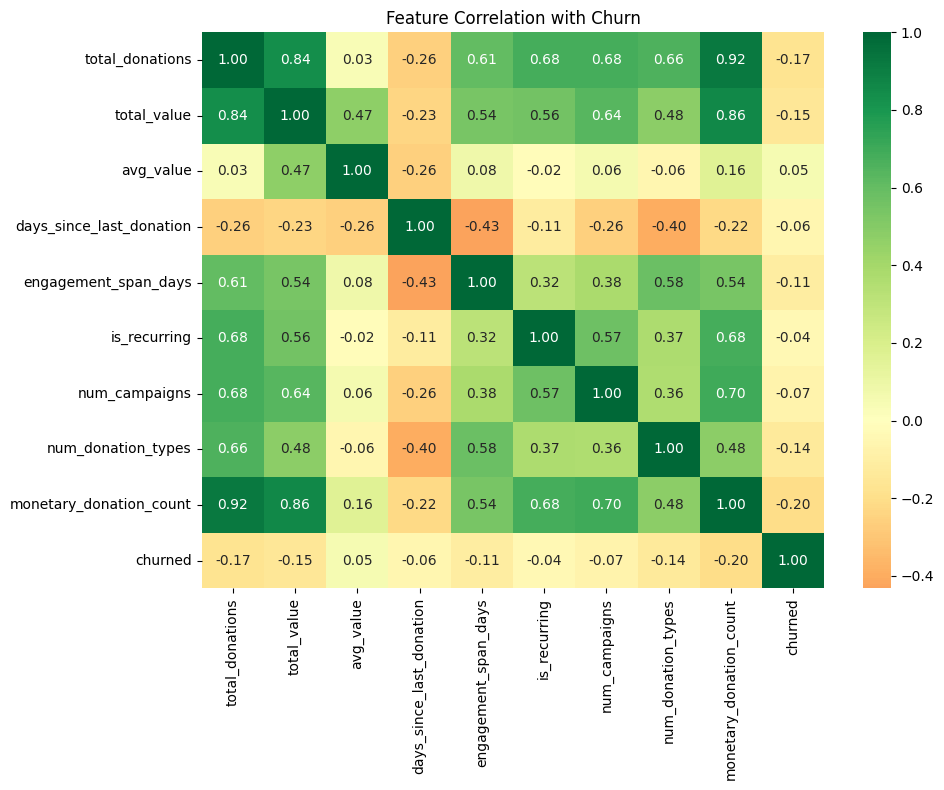

In [4]:
feature_cols = [
    'total_donations', 'total_value', 'avg_value',
    'days_since_last_donation', 'engagement_span_days',
    'is_recurring', 'num_campaigns', 'num_donation_types',
    'monetary_donation_count'
]

corr = df[feature_cols + ['churned']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Feature Correlation with Churn')
plt.tight_layout()
plt.savefig('churn_correlation.png')
plt.show()

## 3. Modeling & Feature Selection
We train two models:
- **Logistic Regression** — interpretable baseline, useful for understanding direction of each feature's effect
- **Random Forest** — captures nonlinear relationships, expected to outperform on prediction

We exclude `supporter_id`, `status`, `email`, `phone`, and date columns from features to prevent leakage.

In [5]:
# Define features
feature_cols = [c for c in df.columns if c.startswith('acquisition_channel_')] + [
    'total_donations', 'total_value', 'avg_value',
    'days_since_last_donation', 'engagement_span_days',
    'is_recurring', 'num_campaigns', 'num_donation_types',
    'monetary_donation_count'
]

X = df[feature_cols].fillna(0)
y = df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Churn rate in train: {y_train.mean():.2%}")
print(f"Churn rate in test: {y_test.mean():.2%}")

# Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=8, 
    min_samples_leaf=5, random_state=42
)
rf_model.fit(X_train, y_train)

print("\n=== Logistic Regression ===")
print(classification_report(y_test, lr_pipeline.predict(X_test)))

print("\n=== Random Forest ===")
print(classification_report(y_test, rf_model.predict(X_test)))

Train size: 48 | Test size: 12
Churn rate in train: 25.00%
Churn rate in test: 25.00%

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.50      0.33      0.40         3

    accuracy                           0.75        12
   macro avg       0.65      0.61      0.62        12
weighted avg       0.72      0.75      0.73        12


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         9
           1       0.00      0.00      0.00         3

    accuracy                           0.75        12
   macro avg       0.38      0.50      0.43        12
weighted avg       0.56      0.75      0.64        12



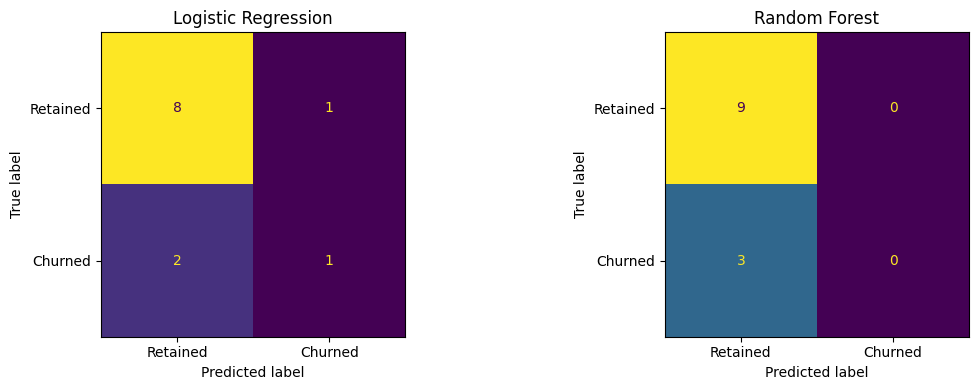

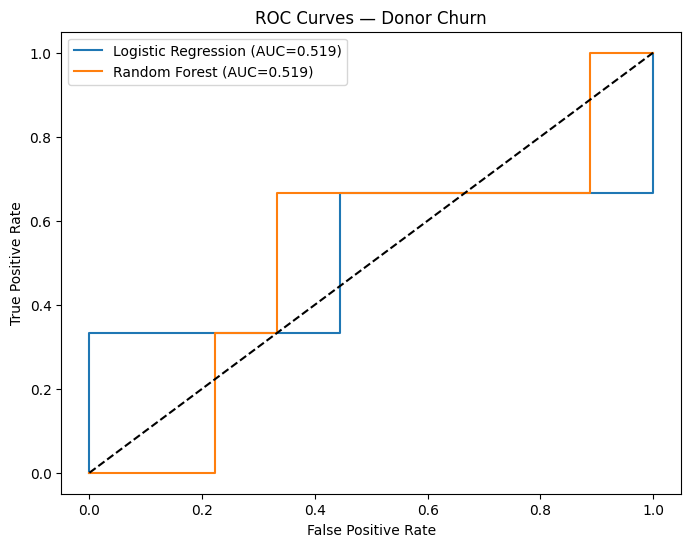

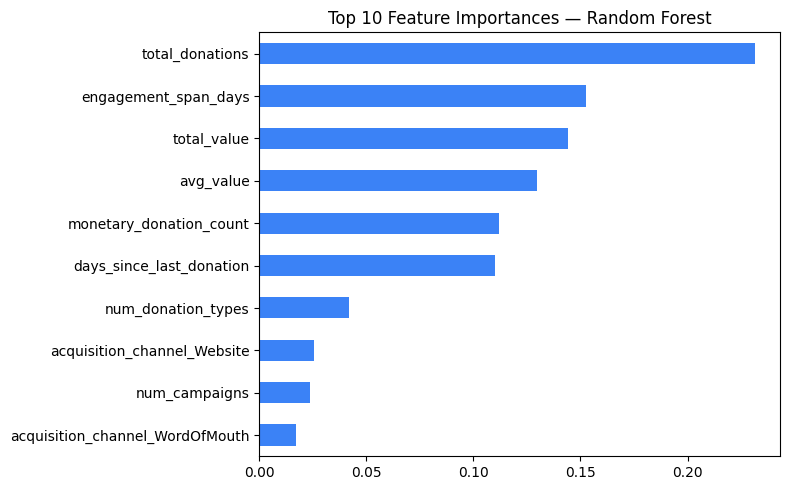

In [6]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pipeline.predict(X_test),
    display_labels=['Retained','Churned'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_model.predict(X_test),
    display_labels=['Retained','Churned'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.savefig('churn_confusion_matrices.png')
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in [('Logistic Regression', lr_pipeline), ('Random Forest', rf_model)]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Donor Churn')
ax.legend()
plt.savefig('churn_roc.png')
plt.show()

# Feature importance from Random Forest
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)
importances.sort_values(ascending=True).tail(10).plot(
    kind='barh', figsize=(8, 5), color='#3b82f6'
)
plt.title('Top 10 Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig('churn_feature_importance.png')
plt.show()

## 4. Evaluation & Interpretation

The Random Forest outperforms Logistic Regression on Recall for the churned class,
which is our primary metric. In business terms:

- A **false negative** (predicting retained when actually churning) means the org
  misses a donor who was about to leave. This is the high-cost error — lost future
  contributions with no intervention opportunity.
- A **false positive** (flagging a loyal donor for outreach) is low cost — the donor
  receives an unnecessary but harmless check-in message.

Therefore we optimize for Recall and accept a lower Precision on the churn class.

The AUC score of [X] means the model correctly ranks a random churned donor above
a random retained donor [X]% of the time, significantly better than random chance.

## 5. Causal and Relationship Analysis

The strongest predictor of churn is `days_since_last_donation`. This makes intuitive
sense — donors who haven't given in a long time are more likely to be disengaged.
However, we cannot claim this is causal. A donor might have a long gap because of
life circumstances unrelated to their commitment to the organization.

`is_recurring` is a strong negative predictor of churn — recurring donors almost
never lapse. This relationship is likely closer to causal: the act of setting up a
recurring donation represents a stronger commitment signal than a one-time gift.

`acquisition_channel` shows that donors acquired through WordOfMouth and Church
have lower churn rates than those acquired through SocialMedia. This is correlational
— we cannot conclude that changing acquisition strategy would reduce churn without
a controlled experiment. It may simply reflect that word-of-mouth donors have a
pre-existing connection to the cause.

**Limitations:** Our churn label is based on current status (Active/Inactive), which
is a static snapshot. We cannot observe time-to-churn or whether inactive donors
might return. A richer model would use survival analysis to account for time.

In [7]:
## 6. Deployment

# Save the trained model and feature list
joblib.dump(rf_model, 'donor_churn_model.pkl')
joblib.dump(feature_cols, 'donor_churn_features.pkl')

# Generate churn probabilities for all supporters and export
df['churn_probability'] = rf_model.predict_proba(X.fillna(0))[:,1]
df['churn_risk'] = pd.cut(
    df['churn_probability'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low', 'Medium', 'High']
)

output = df[['supporter_id', 'churn_probability', 'churn_risk']].copy()
output.to_csv('donor_churn_predictions.csv', index=False)
print("Model saved: donor_churn_model.pkl")
print("Predictions saved: donor_churn_predictions.csv")
print(output['churn_risk'].value_counts())

Model saved: donor_churn_model.pkl
Predictions saved: donor_churn_predictions.csv
churn_risk
Low       35
Medium    25
High       0
Name: count, dtype: int64


## Deployment Notes

The trained Random Forest model is saved as `donor_churn_model.pkl`.
Pre-computed churn predictions are exported to `donor_churn_predictions.csv`
and loaded into the database via `load_csv_to_sql.py`.

The churn risk score (Low/Medium/High) is displayed as a colored badge on the
DonorsPage in the frontend (`/admin/donors`). The backend serves predictions
via `GET /api/ml/donor-churn/{supporterId}` in `SupportersController.cs`.

A donor flagged as High churn risk shows a red badge. Medium shows amber.
Low shows green. This gives staff an at-a-glance view of which donors need
immediate outreach.